run_all_analyses.py
│
├── data_preprocessing.py
│
├── analysis_all.py
│     ├── NutrientMatrix
│     └── NutrientPlotter
│
├── analysis_top10_cuisine_individually.py
│     ├── NutrientMatrix
│     └── NutrientPlotter
│
├── analysis_top10_cuisine_combined.py
│     ├── NutrientMatrix
│     └── CombinedPlotter
│
└── analysis_all_cuisines_csv.py

In [44]:
# ============================================================
# Cell 1: Imports and Global Configuration
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    norm,
    lognorm,
    gamma,
    weibull_min,
    expon,
    uniform,
    kstest,
    skew
)

warnings.filterwarnings("ignore")

# ------------------------------
# Plotting Style
# ------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ------------------------------
# Dataset Configuration
# ------------------------------
DATA_PATH = "DATA/PROCESSED/RecipeDB_Cuisine.csv"

NUTRIENT_COLS = [
    "Carbohydrate, by difference (g)",
    "Protein (g)",
    "Total lipid (fat) (g)"
]

NUTRIENT_SHORT = {
    "Carbohydrate, by difference (g)": "Carbohydrate",
    "Protein (g)": "Protein",
    "Total lipid (fat) (g)": "Fat"
}

print("Environment ready.")
print(f"Number of nutrients selected: {len(NUTRIENT_COLS)}")

Environment ready.
Number of nutrients selected: 3


Cell 1: Imports and Global Configuration

This cell prepares the analysis environment by:

- Importing libraries for data handling (`pandas`, `numpy`)
- Importing visualization tools (`matplotlib`, `seaborn`)
- Importing statistical distributions and tests from `scipy.stats`
- Setting global plotting styles for consistent figures
- Defining the dataset path
- Selecting the three macronutrients of interest:
  - Carbohydrate
  - Protein
  - Fat
- Creating short names for cleaner plot labels

No analysis is performed in this cell; it simply sets up all tools and parameters used throughout the notebook.

In [45]:
# ============================================================
# Cell 2: Load Dataset and Initial Exploration
# ============================================================

# Load processed dataset
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal recipes      : {len(df):,}")
print(f"Total columns      : {df.shape[1]}")
print(f"Total cuisines     : {df['cuisine'].nunique()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
display(df[NUTRIENT_COLS].isna().sum())

print("\nNutrient summary statistics:")
display(df[NUTRIENT_COLS].describe().T)

print("\nCuisine distribution (Top 10):")
display(df['cuisine'].value_counts().head(10))

DATASET OVERVIEW

Total recipes      : 118,083
Total columns      : 9
Total cuisines     : 26

First 5 rows:


,Recipe_id,Region,Sub_region,Continent,"Carbohydrate, by difference (g)",Energy (kcal),Protein (g),Total lipid (fat) (g),cuisine
0,2610,Middle Eastern,Egyptian,African,146.7606,805.6975,49.5540,5.6564,Middle Eastern
1,2611,Middle Eastern,Egyptian,African,39.3312,386.7670,15.5638,19.7239,Middle Eastern
2,2612,Middle Eastern,Egyptian,African,34.0004,1762.7662,82.9034,146.8971,Middle Eastern
3,2613,Middle Eastern,Egyptian,African,225.1172,1686.8298,67.8589,62.4829,Middle Eastern
4,2614,Middle Eastern,Egyptian,African,83.0609,1006.2380,26.1800,73.1713,Middle Eastern



Missing values:


Carbohydrate, by difference (g)    1044
Protein (g)                        1044
Total lipid (fat) (g)              1044
dtype: int64


Nutrient summary statistics:


,count,mean,std,min,25%,50%,75%,max
"Carbohydrate, by difference (g)",117039.0,835.972820,6758.136886,0.0,22.94395,64.3133,199.95245,252062.6800
Protein (g),117039.0,509.474261,4077.491455,0.0,13.68110,49.5069,124.62555,178134.3738
Total lipid (fat) (g),117039.0,488.816511,4345.346591,0.0,17.72930,54.5035,123.51010,363846.9756



Cuisine distribution (Top 10):


cuisine
Italian                  16574
Mexican                  14447
South American            7171
Canadian                  6694
Indian Subcontinent       6463
French                    6375
Chinese and Mongolian     5888
Australian                5819
US                        5025
UK                        4396
Name: count, dtype: int64

Cell 2: Load Dataset and Initial Exploration

This cell loads the processed recipe dataset and performs a preliminary inspection to understand its structure and quality before any statistical analysis.

### Key Observations

- The dataset contains **118,083 recipes** from **26 cuisines**.
- There are **9 columns**, including nutrient information and cuisine metadata.
- The analysis focuses on three macronutrients:
  - Carbohydrate
  - Protein
  - Fat

### Data Quality Check

- Each nutrient column contains **1,044 missing values**.
- Missing values represent less than 1% of the dataset and will be handled in later preprocessing steps.

### Nutrient Characteristics

- Nutrient values span a very large range:
  - Carbohydrates: 0 – 252,063 g
  - Protein: 0 – 178,134 g
  - Fat: 0 – 363,847 g
- Standard deviations are much larger than the means, indicating highly variable and strongly right-skewed distributions.

### Cuisine Distribution

The dataset is not perfectly balanced across cuisines.

Largest cuisines include:

1. Italian (16,574 recipes)
2. Mexican (14,447 recipes)
3. South American (7,171 recipes)
4. Canadian (6,694 recipes)
5. Indian Subcontinent (6,463 recipes)

These top cuisines will later be used for comparative analysis.

### Purpose of This Cell

Before applying statistical models, we verify:

- Dataset size and coverage
- Presence of missing values
- Basic nutrient statistics
- Representation of different cuisines

This provides confidence that the dataset is suitable for studying nutrient distribution patterns across recipes.

In [46]:
# ============================================================
# Cell 3: Data Cleaning and Basic Exploration
# ============================================================

# Keep only nutrient columns
nutrient_df = df[NUTRIENT_COLS].copy()

# Remove rows with missing values
nutrient_df = nutrient_df.dropna()

print(f"Rows remaining: {len(nutrient_df):,}")

# ------------------------------------------------------------
# Number of zero values
# ------------------------------------------------------------

print("\nZero-value counts:")

for nutrient in NUTRIENT_COLS:
    zeros = (nutrient_df[nutrient] == 0).sum()
    pct = 100 * zeros / len(nutrient_df)

    print(
        f"{NUTRIENT_SHORT[nutrient]:<15}"
        f"{zeros:>8,} ({pct:.2f}%)"
    )

Rows remaining: 117,039

Zero-value counts:
Carbohydrate      1,738 (1.48%)
Protein           1,335 (1.14%)
Fat                 956 (0.82%)


Cell 3: Data Cleaning

This cell prepares the nutrient data for analysis by:

- Keeping only carbohydrate, protein, and fat columns.
- Removing rows with missing nutrient values.
- Checking the number of zero-valued nutrients.

Since later analyses use logarithms, identifying zero values is important because \(\log(0)\) is undefined. Fortunately, zero values account for less than 2% of the dataset for all three nutrients.

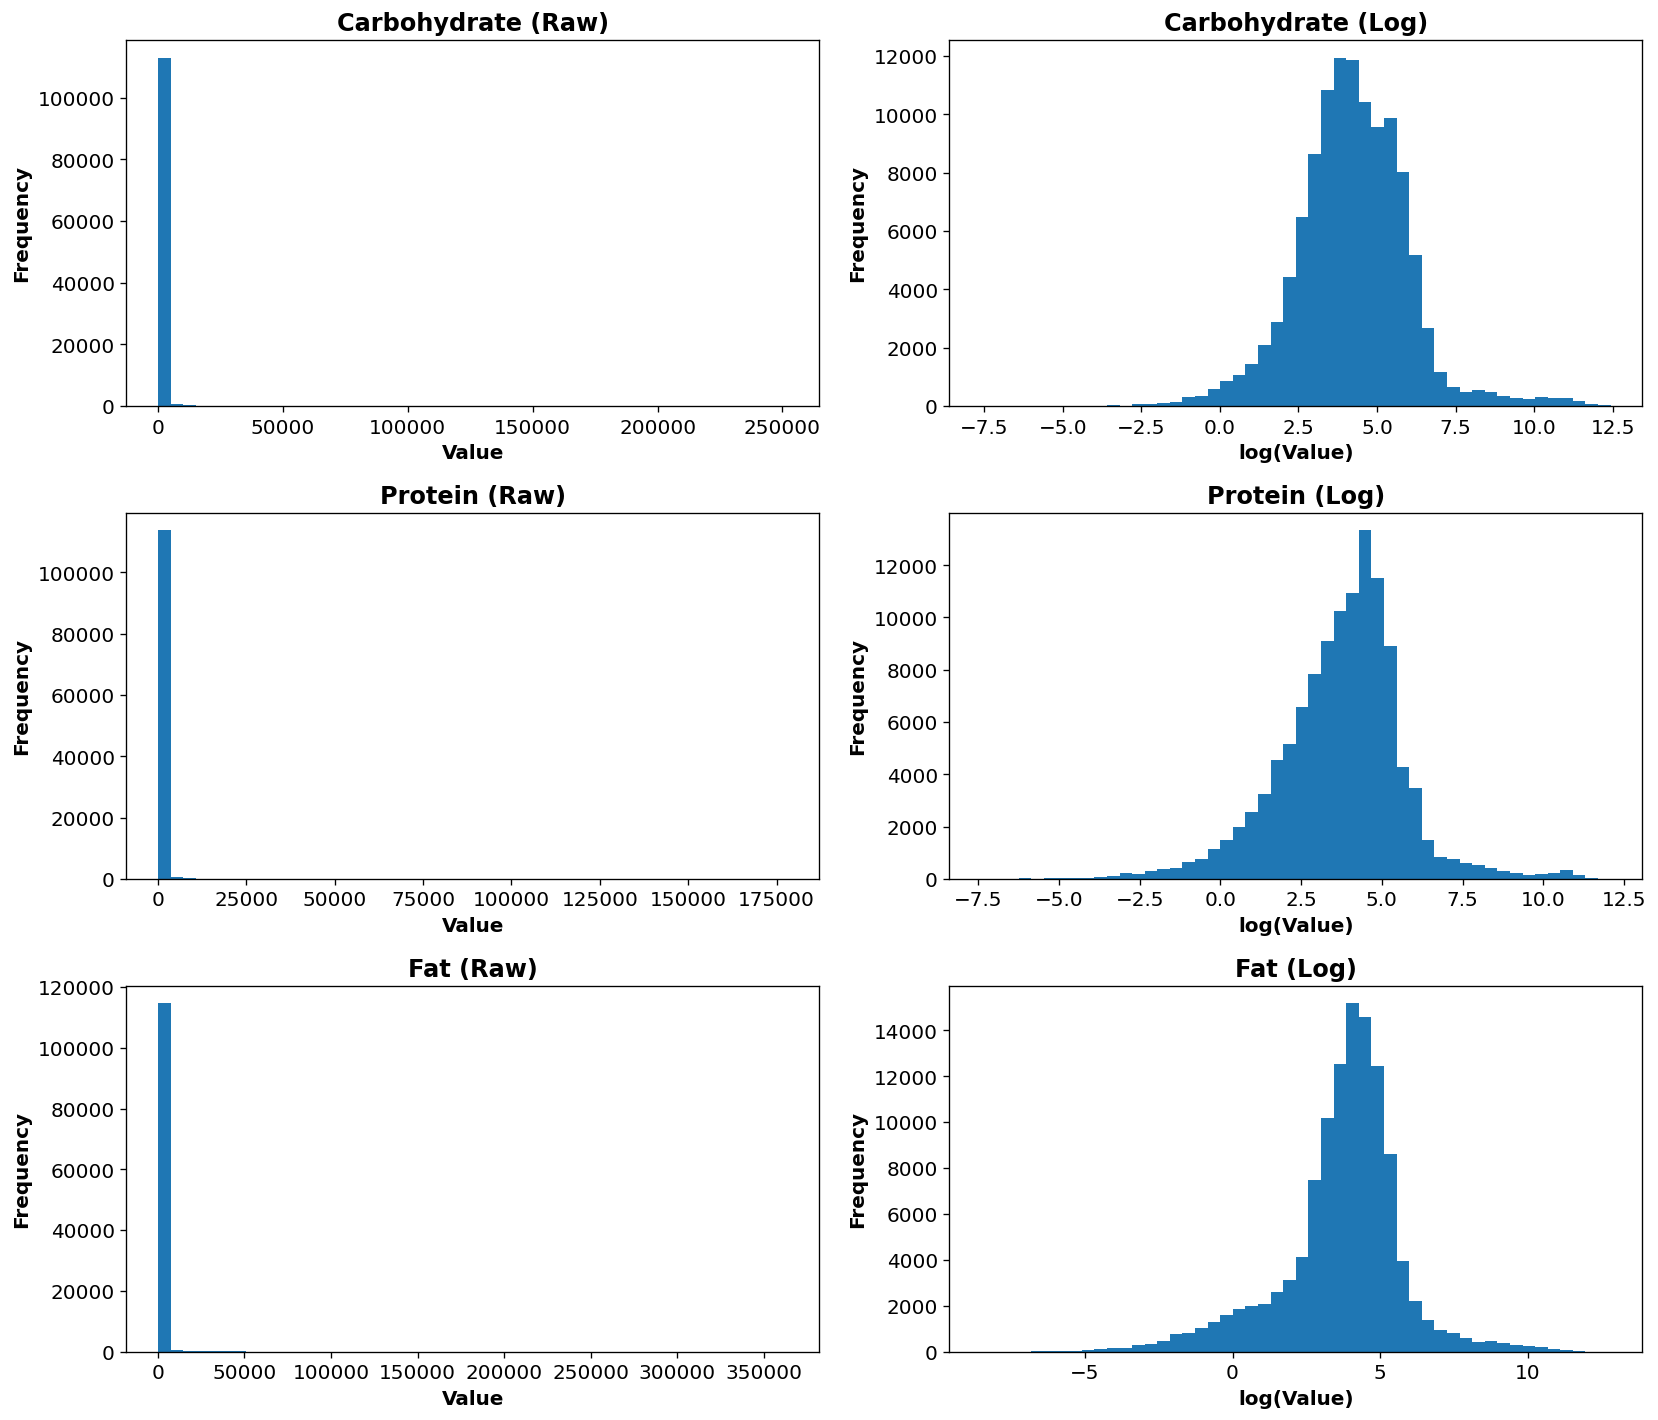

In [47]:
# ============================================================
# Cell 4: Raw vs Log Nutrient Distributions
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

for i, nutrient in enumerate(NUTRIENT_COLS):

    values = nutrient_df[nutrient]
    positive_values = values[values > 0]

    # -------------------------
    # Raw distribution
    # -------------------------
    axes[i, 0].hist(
        positive_values,
        bins=50
    )

    axes[i, 0].set_title(
        f"{NUTRIENT_SHORT[nutrient]} (Raw)"
    )

    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")

    # -------------------------
    # Log distribution
    # -------------------------
    log_values = np.log(positive_values)

    axes[i, 1].hist(
        log_values,
        bins=50
    )

    axes[i, 1].set_title(
        f"{NUTRIENT_SHORT[nutrient]} (Log)"
    )

    axes[i, 1].set_xlabel("log(Value)")
    axes[i, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Cell 4: Raw vs Log Nutrient Distributions

This cell compares the distributions of carbohydrate, protein, and fat before and after applying a logarithmic transformation.

### Key Observations

- Raw nutrient distributions are highly right-skewed, with a few recipes containing extremely large nutrient values.
- Taking the logarithm compresses these extreme values and produces distributions that are much closer to a symmetric bell shape.
- This suggests that nutrient concentrations may follow a **lognormal distribution**, motivating the use of log-space statistics in later analyses.

### Purpose

To justify analyzing nutrients in log-space rather than raw space.

In [48]:
# ============================================================
# Cell 5: Investigate Extreme Nutrient Values
# ============================================================

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]

    print("\n" + "="*60)
    print(NUTRIENT_SHORT[nutrient])
    print("="*60)

    print(f"Maximum value : {values.max():,.2f}")
    print(f"99th percentile : {values.quantile(0.99):,.2f}")
    print(f"99.9th percentile : {values.quantile(0.999):,.2f}")

    print("\nTop 10 largest values:")
    print(values.nlargest(10).to_list())


Carbohydrate
Maximum value : 252,062.68
99th percentile : 20,179.47
99.9th percentile : 100,805.85

Top 10 largest values:
[252062.68, 241915.2, 241719.1529, 235037.2608, 222051.9192, 217882.3552, 207303.8265, 205171.0318, 201256.17, 191291.2601]

Protein
Maximum value : 178,134.37
99th percentile : 8,981.00
99.9th percentile : 62,752.21

Top 10 largest values:
[178134.3738, 167162.197, 148417.6265, 119342.3548, 108087.1258, 108046.8904, 106749.9178, 105748.6865, 98344.2423, 94239.7287]

Fat
Maximum value : 363,846.98
99th percentile : 9,276.63
99.9th percentile : 64,171.09

Top 10 largest values:
[363846.9756, 300570.3075, 254332.2912, 222710.5494, 218000.0, 214789.595, 160519.9559, 150286.1547, 150281.7839, 149432.3743]


## Cell 5: Investigating Extreme Nutrient Values

This cell examines the largest nutrient values in the dataset to identify potential outliers.

### Key Observations

- All three nutrients contain extremely large values compared to their typical ranges.
- The maximum values are much larger than the 99th percentile, indicating the presence of a small number of extreme observations.
- These extreme values explain the strong right-skewness observed in the raw distributions.

### Purpose

To understand the impact of outliers and motivate the use of logarithmic transformations, which reduce the influence of extremely large nutrient values.

In [49]:
# ============================================================
# Cell 6: Log-Space Statistics
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": np.mean(log_values),
        "Std(log x)": np.std(log_values, ddof=1),
        "Skew(log x)": stats.skew(log_values, bias=False),
        "Median(log x)": np.median(log_values)
    })

log_stats_df = pd.DataFrame(records)

display(log_stats_df.round(4))

,Nutrient,Mean(log x),Std(log x),Skew(log x),Median(log x)
0,Carbohydrate,4.2188,1.7867,0.2067,4.1908
1,Protein,3.7218,1.9380,-0.2635,3.9261
2,Fat,3.7112,2.0691,-0.6741,4.0085


## Cell 6: Log-Space Statistics

This cell computes summary statistics after applying a logarithmic transformation to nutrient values.

### Key Observations

- The mean log-values are similar across nutrients (≈ 3.7–4.2).
- Log-space standard deviations are relatively close (≈ 1.8–2.1), suggesting comparable variability across nutrients.
- Log-space skewness values are much closer to zero than in raw space, indicating more symmetric distributions.
- The similarity between the mean and median further supports approximate symmetry in log-space.

### Purpose

To quantify the location, spread, and symmetry of nutrient distributions after log transformation and assess whether they exhibit approximately lognormal behavior.

In [50]:
# ============================================================
# Cell 7: Normality Tests in Log Space
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    # KS test against fitted Gaussian
    mu, sigma = norm.fit(log_values)

    D, p = kstest(
        log_values,
        'norm',
        args=(mu, sigma)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": mu,
        "Std(log x)": sigma,
        "KS Distance": D,
        "p-value": p
    })

normality_df = pd.DataFrame(records)

display(normality_df.round(6))

,Nutrient,Mean(log x),Std(log x),KS Distance,p-value
0,Carbohydrate,4.218754,1.786740,0.042960,0.0
1,Protein,3.721802,1.938007,0.064728,0.0
2,Fat,3.711236,2.069095,0.110508,0.0


## Cell 7: Normality Tests in Log Space

This cell evaluates how closely log-transformed nutrient values follow a Gaussian (normal) distribution using the Kolmogorov–Smirnov (KS) test.

### Key Observations

- All nutrients have relatively small KS distances (0.04–0.11), indicating reasonable agreement with a Gaussian distribution in log-space.
- Carbohydrate shows the best fit (smallest KS distance).
- Fat shows the largest deviation from normality.
- The very large sample size causes p-values to be effectively zero, so the KS distance is more informative than the p-value.

### Purpose

To test the hypothesis that nutrient concentrations are approximately **lognormally distributed**, meaning their logarithms resemble a normal distribution.

,"Carbohydrate, by difference (g)",Protein (g),Total lipid (fat) (g)
"Carbohydrate, by difference (g)",1.000,0.397,0.362
Protein (g),0.397,1.000,0.599
Total lipid (fat) (g),0.362,0.599,1.000


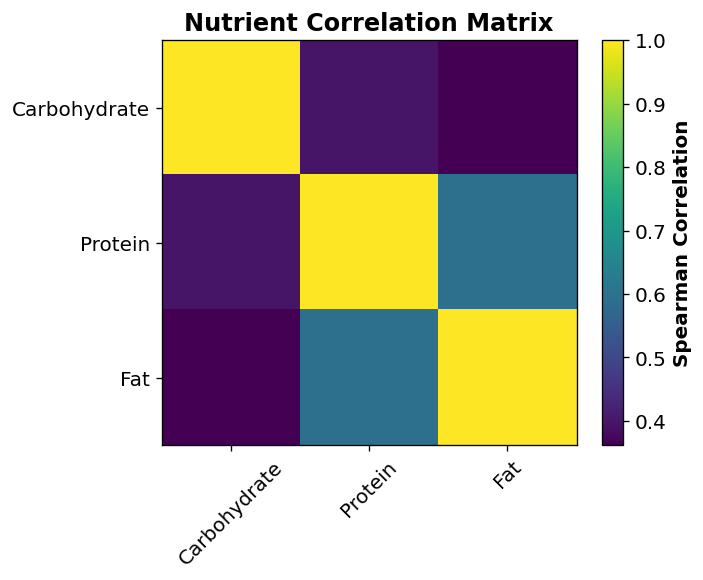

In [51]:
# ============================================================
# Cell 8: Nutrient Correlation Matrix
# ============================================================

corr_matrix = nutrient_df[NUTRIENT_COLS].corr(method="spearman")

display(corr_matrix.round(3))

plt.figure(figsize=(6,5))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(NUTRIENT_COLS)),
    [NUTRIENT_SHORT[n] for n in NUTRIENT_COLS],
    rotation=45
)

plt.yticks(
    range(len(NUTRIENT_COLS)),
    [NUTRIENT_SHORT[n] for n in NUTRIENT_COLS]
)

plt.title("Nutrient Correlation Matrix")
plt.tight_layout()
plt.show()

## Cell 8: Nutrient Correlation Analysis

This cell measures the relationships between carbohydrate, protein, and fat using Spearman correlation.

### Key Observations

- All nutrient pairs show positive correlations.
- Protein and fat are the most strongly correlated (ρ = 0.599).
- Carbohydrate has moderate correlations with both protein (ρ = 0.397) and fat (ρ = 0.362).

### Purpose

To determine whether recipes rich in one nutrient also tend to be rich in others and to identify dependencies between macronutrients.

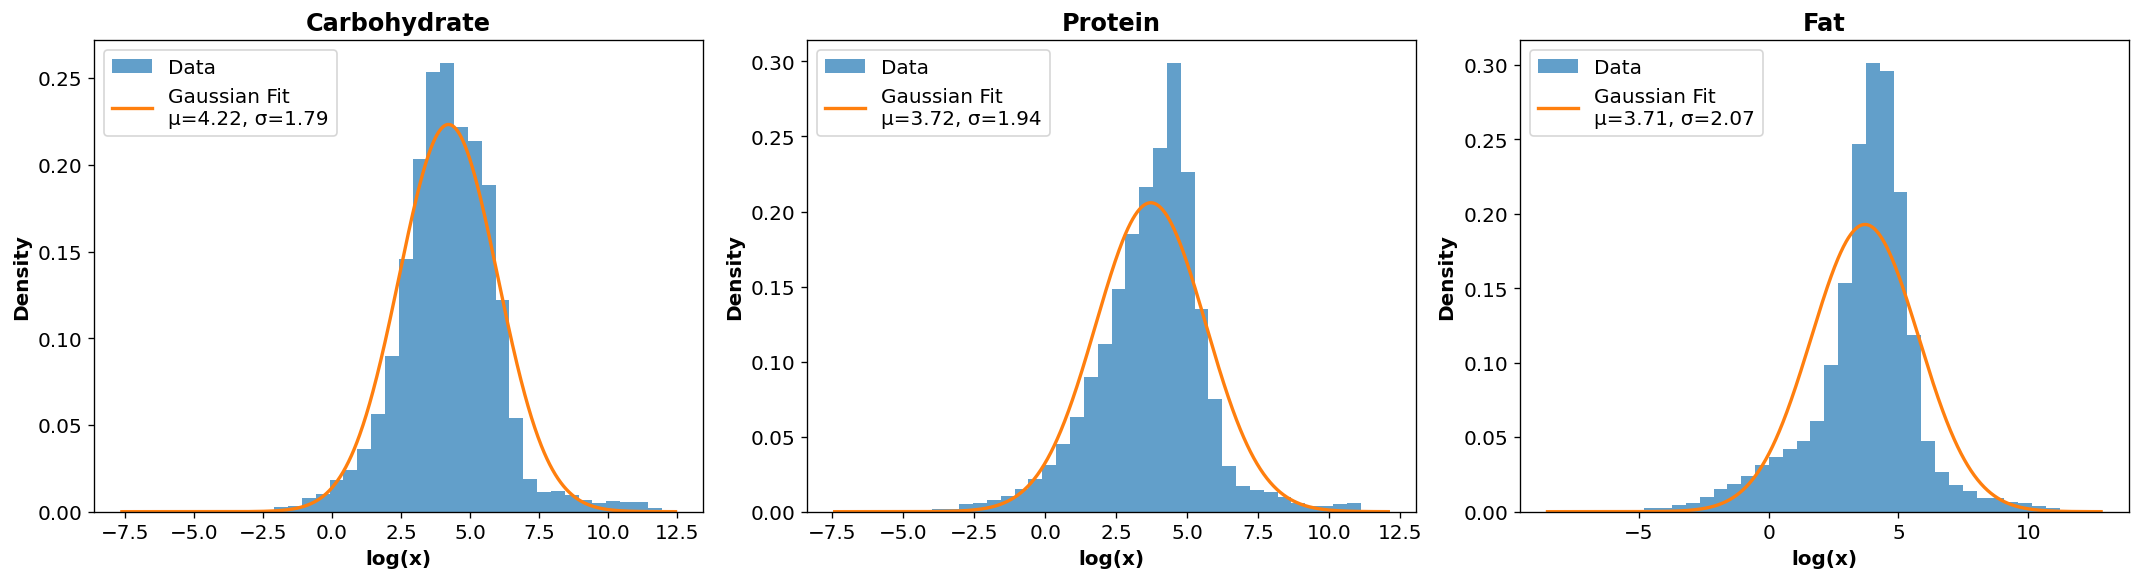

In [52]:
# ============================================================
# Cell 9: Nutrient Distributions Q(x_n)
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, nutrient in zip(axes, NUTRIENT_COLS):

    values = nutrient_df[nutrient]
    values = values[values > 0]

    # Histogram in log-space
    log_values = np.log(values)

    ax.hist(
        log_values,
        bins=40,
        density=True,
        alpha=0.7,
        label="Data"
    )

    # Gaussian fit
    mu, sigma = norm.fit(log_values)

    x = np.linspace(
        log_values.min(),
        log_values.max(),
        1000
    )

    ax.plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2,
        label=f"Gaussian Fit\nμ={mu:.2f}, σ={sigma:.2f}"
    )

    ax.set_title(NUTRIENT_SHORT[nutrient])
    ax.set_xlabel("log(x)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## Cell 9: Nutrient Distributions \(Q(x_n)\)

This cell visualizes the log-transformed nutrient distributions and compares them with fitted Gaussian curves.

### Key Observations

- The Gaussian curves closely follow the observed distributions.
- Carbohydrate shows the best agreement with a Gaussian distribution.
- Protein and fat exhibit slight deviations, particularly in the tails.
- Overall, the distributions appear approximately normal in log-space.

### Purpose

To visually validate the hypothesis that nutrient concentrations are approximately **lognormally distributed**, complementing the KS-test results from Cell 7.

In [53]:
# ============================================================
# Cell 10: Constant Log-Standard Deviation
# ============================================================

log_std_values = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    s_n = np.std(log_values, ddof=1)

    log_std_values.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "s_n": s_n
    })

log_std_df = pd.DataFrame(log_std_values)

display(log_std_df)

mean_s = log_std_df["s_n"].mean()
std_s = log_std_df["s_n"].std(ddof=1)

print(f"\nMean s_n = {mean_s:.4f}")
print(f"Std  s_n = {std_s:.4f}")
print(f"CV       = {100*std_s/mean_s:.2f}%")

,Nutrient,s_n
0,Carbohydrate,1.786747
1,Protein,1.938015
2,Fat,2.069104



Mean s_n = 1.9313
Std  s_n = 0.1413
CV       = 7.32%


## Cell 10: Constant Log-Standard Deviation

This cell tests whether the spread of nutrient distributions is similar in log-space.

### Key Observations

- The log-standard deviations are relatively close:
  - Carbohydrate: 1.79
  - Protein: 1.94
  - Fat: 2.07
- The coefficient of variation (CV) is only **7.3%**, indicating limited variation across nutrients.

### Purpose

To investigate the **constant log-standard deviation law**, which suggests that different nutrients exhibit a similar level of variability after log transformation.

,Nutrient,Mean(log x),Skew(log x)
0,Carbohydrate,4.2188,0.2067
1,Protein,3.7218,-0.2635
2,Fat,3.7112,-0.6741


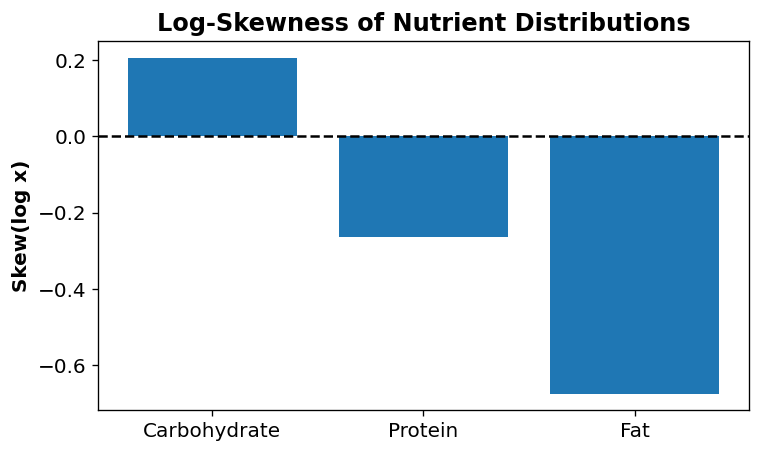

In [55]:
# ============================================================
# Cell 11: Log-Skewness Analysis
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": np.mean(log_values),
        "Skew(log x)": stats.skew(log_values, bias=False)
    })

skew_df = pd.DataFrame(records)

display(skew_df.round(4))

plt.figure(figsize=(7,4))

plt.bar(
    skew_df["Nutrient"],
    skew_df["Skew(log x)"]
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.ylabel("Skew(log x)")
plt.title("Log-Skewness of Nutrient Distributions")

plt.show()

## Cell 11: Log-Skewness Analysis

This cell measures the asymmetry of nutrient distributions in log-space.

### Key Observations

- Log-skewness values are relatively close to zero.
- Carbohydrate shows slight positive skewness (+0.21).
- Protein and fat show mild negative skewness (-0.26 and -0.67).
- Overall, nutrient distributions are approximately symmetric after log transformation.

### Purpose

To test whether nutrient distributions become nearly symmetric in log-space, providing further evidence for approximate lognormal behavior.

| Section                    | Status |
| -------------------------- | ------ |
| Dataset overview           | Done   |
| Missing values             | Done   |
| Zero values                | Done   |
| Raw distributions          | Done   |
| Log distributions          | Done   |
| Outlier analysis           | Done   |
| Lognormality check         | Done   |
| KS normality test          | Done   |
| Constant (s_n) law         | Done   |
| Log-skewness               | Done   |
| Correlation analysis (new) | Done   |
